In [1]:
import numpy as np
import matplotlib .pylab as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,accuracy_score,mean_squared_error



In [2]:
df=pd.read_csv("Advertising dataset (2).csv")
df

,Unnamed: 0,TV,radio,newspaper,sales
0,0,230.1,37.8,69.2,22.1
1,1,44.5,39.3,45.1,10.4
2,2,17.2,45.9,69.3,9.3
3,3,151.5,41.3,58.5,18.5
4,4,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,195,38.2,3.7,13.8,7.6
196,196,94.2,4.9,8.1,9.7
197,197,177.0,9.3,6.4,12.8
198,198,283.6,42.0,66.2,25.5


In [30]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0',axis=1)

In [31]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [33]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [34]:
df.duplicated().sum()

0

In [35]:
# Correlation Metrics

corr_metrix=df.corr()
print(corr_metrix.sort_values(by='sales',ascending=False))

                 TV     radio  newspaper     sales
sales      0.782224  0.576223   0.228299  1.000000
TV         1.000000  0.054809   0.056648  0.782224
radio      0.054809  1.000000   0.354104  0.576223
newspaper  0.056648  0.354104   1.000000  0.228299


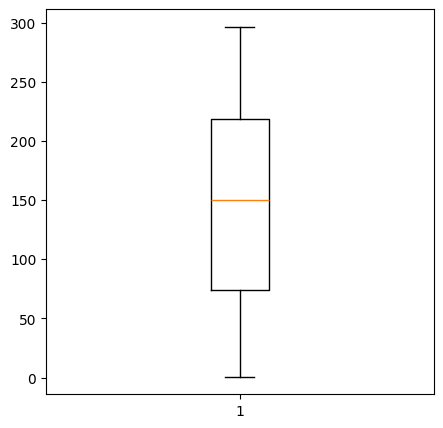

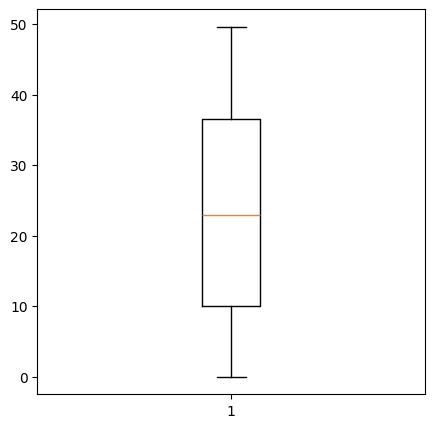

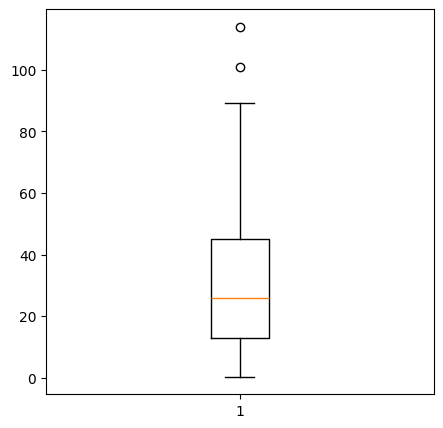

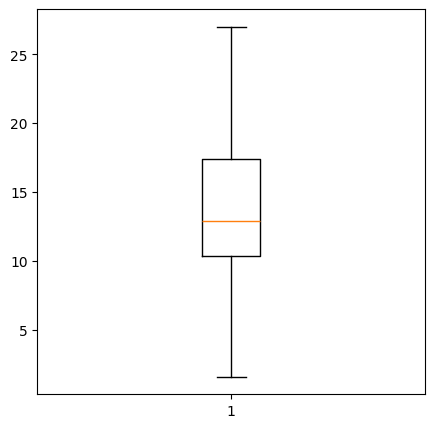

In [9]:
import matplotlib.pyplot  as plt
for i in df.columns:
    plt.figure(figsize=(5,5))
    plt.boxplot(df[i])
    plt.show()

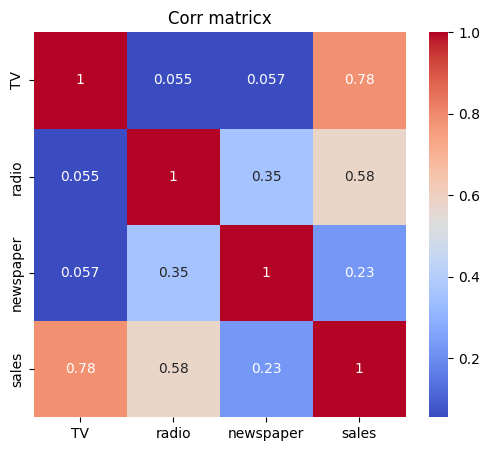

In [36]:
# Heatmap visua;ization

plt.figure(figsize=(6,5))
sns.heatmap(corr_metrix,annot=True,cmap='coolwarm')
plt.title("Corr matricx")
plt.show()

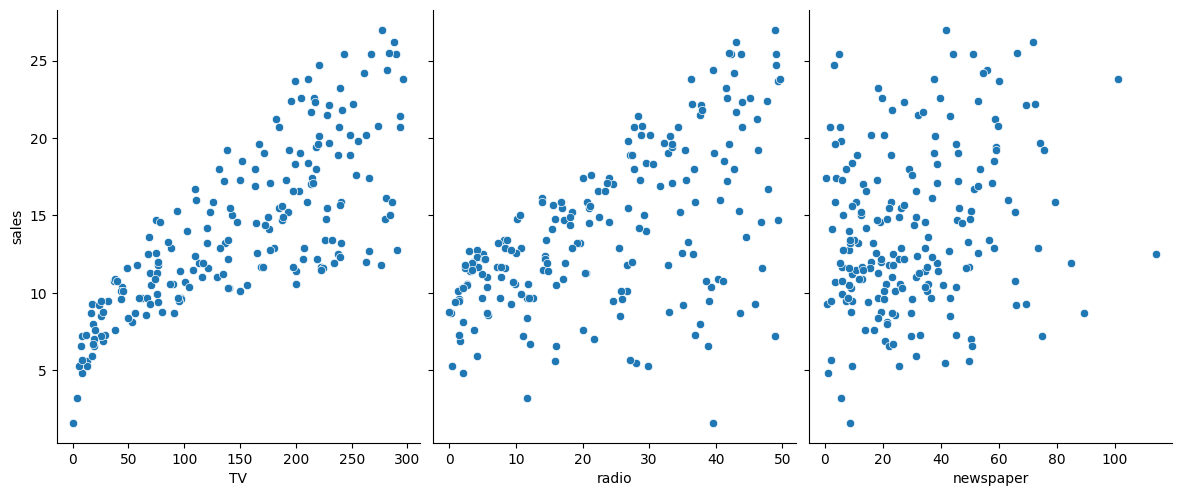

In [11]:
sns.pairplot(df,x_vars=['TV','radio','newspaper'],y_vars='sales',height=5,aspect=0.8)
plt.show()

In [20]:
# prepare for data regression
x=df.loc[:,['TV','radio','newspaper']]
y=df['sales']

In [21]:
x

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [22]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [15]:
! pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
! pip install numpy==1.26.4
! pip install pandas==2.2.2


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import statsmodels.api as sm
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
x_train_sm=sm.add_constant(x_train)
x_test_sm=sm.add_constant(x_test)


In [24]:
full_model =sm.OLS(y_train,x_train_sm).fit()
print(full_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     446.6
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           2.53e-76
Time:                        12:01:14   Log-Likelihood:                -306.64
No. Observations:                 160   AIC:                             621.3
Df Residuals:                     156   BIC:                             633.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9791      0.354      8.427      0.0

In [25]:
print("\nEstimated Regression Equation")

print(
    f"Sales = {full_model.params['const']:.4f} "
    f"+ {full_model.params['TV']:.4f}*TV "
    f"+ {full_model.params['radio']:.4f}*Radio "
    f"+ {full_model.params['newspaper']:.4f}*Newspaper"
)

print(f"\nR-squared: {full_model.rsquared:.4f}")


Estimated Regression Equation
Sales = 2.9791 + 0.0447*TV + 0.1892*Radio + 0.0028*Newspaper

R-squared: 0.8957


In [27]:
# r squared
print(f"R-squared:{full_model.rsquared:4f}")

# model significance
print(f'\nOverall F-statistic :{full_model.fvalue:.2f},p-value:{full_model.f_pvalue:.4f}')

R-squared:0.895701

Overall F-statistic :446.57,p-value:0.0000


In [28]:
y_pred_test =full_model.predict(x_test_sm)
mse=mean_squared_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(f"\nMSE (test):{mse:.4f}")
print(f"RMSE (test):{rmse:.4f}")



MSE (test):3.1741
RMSE (test):1.7816


In [29]:
new_scenarios =pd.DataFrame({
    'const':[1,1],
    "TV":[200,300],
    "radio":[40,20],
    "newspaper":[20,50]
})
prediction=full_model.predict(new_scenarios)
print("\nprediction")
print(f"a) TV=200,radio=40,newspaper=20:sales\u2248 {prediction[0]:.2f}")
print(f"b) TV=100,radio=20,newspaper=50: sales\u2248{prediction[1]:.2f}")



prediction
a) TV=200,radio=40,newspaper=20:sales≈ 19.55
b) TV=100,radio=20,newspaper=50: sales≈20.32
